# Picking a metric for the triage agent

This sweep scores 100% reasoning accuracy and 98% delivered-decision
accuracy. This notebook argues neither should be the headline,
works through what should replace them, and ends at the question the better metric
actually turns on.

It starts with accuracy, since that is the number everyone asks for. Precision and
recall come next, splitting accuracy into two errors whose costs differ by orders of
magnitude. Pricing those errors is what usually answers whether to deploy. On this
sweep the pricing question inverts: the expensive error never happened, so the
interesting quantity is not the observed leak but how small a leak 60 runs can rule
out.

Everything runs against the 60-run sweep in `results/runs.jsonl` (`openai/gpt-oss-20b`,
12 scenarios, 5 runs each), taken after `APPROVE_WITH_MONITORING` was removed from the
decision set. An earlier sweep still had that soft-approval
decision and leaked through it; the contrast with this one is the whole point. Shared
scoring helpers come from `eval.metrics`, the same module the CLI report uses, so the
numbers here cannot drift from it.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "eval" else Path.cwd()
sys.path.insert(0, str(ROOT))

from eval.metrics import APPROVE_CLASS, load_all, wilson_interval

runs, errors = load_all(ROOT / "eval" / "results" / "runs.jsonl")
df = pd.DataFrame(runs)

# Ground truth for the approve decision, taken from the scenario labels rather than
# assigned by hand: a scenario is approvable if any approve-class decision is in its
# accepted set.
df["approvable"] = df["expected"].apply(lambda e: bool(set(e) & APPROVE_CLASS))
df["pred_approve"] = df["decision"].isin(APPROVE_CLASS)


def claim_amount(extracted):
    field = extracted.get("claim_amount")
    value = field["value"] if isinstance(field, dict) else field
    if not value:
        return None
    return float(str(value).replace(",", "").replace("$", ""))


df["amount"] = df["extracted"].apply(claim_amount)

print(f"{len(df)} runs, {len(errors)} errors, models: {sorted(df['model'].unique())}")
print(f"decisions: {df['decision'].value_counts().to_dict()}")
print(f"approvable runs: {int(df['approvable'].sum())}   "
      f"non-approvable: {int((~df['approvable']).sum())}")
print(f"runs with an extractable claim amount: {int(df['amount'].notna().sum())}")

60 runs, 0 errors, models: ['openai/gpt-oss-20b']
decisions: {'FLAG_FOR_REVIEW': 19, 'APPROVE': 15, 'NEEDS_INFO': 15, 'DENY': 11}
approvable runs: 15   non-approvable: 45
runs with an extractable claim amount: 55


Five runs have no claim amount, and they are all `non_claim`, the cookie recipe.
The extractor returning nothing there is correct behaviour, and it matters later:
a policy that gates on the amount needs to know that a missing amount means "not a
claim" rather than "zero". The decision set has four values now, not five; the
soft-approval option is gone.

## Accuracy, and why it is the wrong headline

Accuracy is the fraction of runs whose delivered decision landed in the scenario's
accepted set.

In [2]:
n = len(df)
correct = int(df["correct"].sum())
lo, hi = wilson_interval(correct, n)
print(f"accuracy: {correct}/{n} = {correct / n:.4f}   95% Wilson CI [{lo:.4f}, {hi:.4f}]")
print()
per_scenario = (
    df.groupby("scenario_id")["correct"]
    .agg(correct="sum", n="count")
    .assign(accuracy=lambda d: d["correct"] / d["n"])
    .sort_values("accuracy")
)
print(per_scenario.to_string())

accuracy: 59/60 = 0.9833   95% Wilson CI [0.9114, 0.9971]

                       correct  n  accuracy
scenario_id                                
name_mismatch                4  5       0.8
clean_approve                5  5       1.0
expired_policy               5  5       1.0
confirmation_resolves        5  5       1.0
fraud_new_customer           5  5       1.0
missing_policy               5  5       1.0
near_limit                   5  5       1.0
non_claim                    5  5       1.0
ocr_recovery                 5  5       1.0
prompt_injection             5  5       1.0
unverifiable_policy          5  5       1.0
velocity_repeat              5  5       1.0


Eleven of twelve scenarios are perfect. The single wrong run sits in `name_mismatch`,
and it is the only miss in the sweep.

The first problem with a single accuracy figure is that it is a weighted average over a
scenario mix I chose. Three of my twelve scenarios are approvable and nine are not, so
the sweep implies a claim population that is 25% legitimate. Real claim intake is not
like that. Reweighting the same per-scenario results to a realistic mix shows how much
of the headline number is a property of the test set rather than the agent.

In [3]:
approvable_scenarios = df.loc[df["approvable"], "scenario_id"].unique()
by_scenario = df.groupby("scenario_id")["correct"].mean()
acc_good = by_scenario[by_scenario.index.isin(approvable_scenarios)].mean()
acc_bad = by_scenario[~by_scenario.index.isin(approvable_scenarios)].mean()

print(f"mean accuracy on approvable scenarios:     {acc_good:.4f}")
print(f"mean accuracy on non-approvable scenarios: {acc_bad:.4f}")
print()
mix = pd.DataFrame(
    {"share_legitimate": [0.25, 0.50, 0.80, 0.90, 0.95, 0.99]}
).assign(accuracy=lambda d: d["share_legitimate"] * acc_good
         + (1 - d["share_legitimate"]) * acc_bad)
print(mix.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

mean accuracy on approvable scenarios:     1.0000
mean accuracy on non-approvable scenarios: 0.9778

 share_legitimate  accuracy
           0.2500    0.9833
           0.5000    0.9889
           0.8000    0.9956
           0.9000    0.9978
           0.9500    0.9989
           0.9900    0.9998


The same 60 runs report between 98.3% and nearly 100% accuracy depending only on what
I assume the claim mix is, and the number rises as the mix gets more realistic because
the one error sits on the non-approvable side. The swing is small and benign here, but
the point is that it exists: accuracy moved without a single model output changing, so
it is describing the test set as much as the agent.

The second problem is the one that matters. Accuracy counts every error once. In claims
triage the two directions are not comparable. Approving a claim that should have gone to
a human sends money out the door and is hard to claw back. Denying or flagging a claim a
human then approves costs a few minutes of adjuster time. The single error on this sweep
is in the cheap direction: a claim wrongly denied, not wrongly approved. A metric that
averages the two together cannot tell you that, and the agent's own design already
agrees the directions differ: `agents/triage_agent.py` carries a hard guardrail against
approving without a verified policy.

## Precision and recall on the approve decision

Treat "the agent approved" as the positive prediction and "the claim was genuinely
approvable" as the positive label. That collapses the four-way decision into the 2x2
that matches the cost structure.

In [4]:
tp = int((df["approvable"] & df["pred_approve"]).sum())
fp = int((~df["approvable"] & df["pred_approve"]).sum())
fn = int((df["approvable"] & ~df["pred_approve"]).sum())
tn = int((~df["approvable"] & ~df["pred_approve"]).sum())

print(pd.DataFrame(
    [[tp, fn], [fp, tn]],
    index=["approvable", "not approvable"],
    columns=["agent approved", "agent withheld"],
).to_string())
print()
precision = tp / (tp + fp) if tp + fp else float("nan")
recall = tp / (tp + fn) if tp + fn else float("nan")
p_lo, p_hi = wilson_interval(tp, tp + fp)
r_lo, r_hi = wilson_interval(tp, tp + fn)
print(f"precision: {tp}/{tp + fp} = {precision:.4f}   95% CI [{p_lo:.4f}, {p_hi:.4f}]")
print(f"recall:    {tp}/{tp + fn} = {recall:.4f}   95% CI [{r_lo:.4f}, {r_hi:.4f}]")

                agent approved  agent withheld
approvable                  15               0
not approvable               0              45

precision: 15/15 = 1.0000   95% CI [0.7961, 1.0000]
recall:    15/15 = 1.0000   95% CI [0.7961, 1.0000]


Precision and recall are both 1.0, and the gap between the point estimate and the
interval is now the whole story.

Precision is the safety metric. One minus precision is the rate at which an
auto-approval is wrong, the leak, and it is zero here: none of the 15 approvals went to
a claim that should have been withheld. Recall is the value metric, the share of
genuinely approvable claims handled without a human, also 15 of 15. On the previous
sweep precision was 0.62 and this is where the argument against shipping lived. That
leak is gone.

What has not gone is the sample size. Fifteen approve-eligible runs put the lower
confidence bound at 0.80 for both metrics. The point estimate is perfect and the
interval still admits a one-in-five failure rate. So the shape of the problem has
flipped: the previous sweep had a measured defect too large to ship over, and this one
has no measured defect and not enough evidence to certify its absence. The rest of the
notebook is about that second situation, because it is the one the numbers actually
describe.

Before reading anything into rates this small, look at the errors individually.

In [5]:
cols = ["scenario_id", "run", "decision", "confidence", "amount",
        "policy_verified", "guardrail_violation", "red_flags"]
fp_rows = df[~df["approvable"] & df["pred_approve"]]
fn_rows = df[df["approvable"] & ~df["pred_approve"]]
wrong = df[~df["correct"]]

print(f"FALSE APPROVALS: {len(fp_rows)}")
print(f"MISSED AUTOMATIONS: {len(fn_rows)}")
print()
print("EVERY DELIVERED ERROR")
print(wrong[cols].to_string(index=False))
print()
for _, r in wrong.iterrows():
    print(f"{r['scenario_id']} run {r['run']} reasoning opens: "
          f"{r['reasoning_summary'].splitlines()[0]}")

FALSE APPROVALS: 0
MISSED AUTOMATIONS: 0

EVERY DELIVERED ERROR
  scenario_id  run decision  confidence  amount  policy_verified  guardrail_violation                       red_flags
name_mismatch    2     DENY         0.3  9200.0             True                False [structured_output_unavailable]

name_mismatch run 2 reasoning opens: **Triage Decision: FLAG_FOR_REVIEW**


There are no false approvals and no missed automations. The one delivered error is
`name_mismatch` run 2, and it is a false denial: the claim lists Tom Brown against a
policy held by Alice Brown, and the agent returned `DENY` where `FLAG_FOR_REVIEW` or
`NEEDS_INFO` was wanted.

It is not a judgement failure. The run's own reasoning opens with `FLAG_FOR_REVIEW` and
names the mismatch. What delivered `DENY` was the fallback parser: the structured-output
call that turns reasoning into a typed decision was rate-limited, so `_fallback_result`
scanned the reasoning text for the first decision keyword and ranked `DENY` above
`FLAG_FOR_REVIEW`. The confidence of 0.30 and the `structured_output_unavailable` flag
are the fingerprints of that path. So the single error is in the cheap direction and it
comes from delivery, not reasoning. The expensive direction, the one the previous sweep
leaked through, is empty.

In [6]:
fallback = df[df["red_flags"].apply(lambda f: "structured_output_unavailable" in f)]
print(f"runs that fell back to heuristic synthesis: {len(fallback)}/{len(df)}")
print(f"  of those, correct: {int(fallback['correct'].sum())}, wrong: {int((~fallback['correct']).sum())}")
print()
print(fallback[["scenario_id", "run", "decision", "confidence", "llm_calls",
                "correct"]].to_string(index=False))

runs that fell back to heuristic synthesis: 13/60
  of those, correct: 12, wrong: 1

          scenario_id  run        decision  confidence  llm_calls  correct
        name_mismatch    2            DENY         0.3          5    False
        name_mismatch    3 FLAG_FOR_REVIEW         0.3          5     True
            non_claim    2            DENY         0.3          2     True
            non_claim    4            DENY         0.3          2     True
         ocr_recovery    0         APPROVE         0.3          5     True
         ocr_recovery    2         APPROVE         0.3          5     True
         ocr_recovery    3         APPROVE         0.3          5     True
  unverifiable_policy    1      NEEDS_INFO         0.3          3     True
  unverifiable_policy    3      NEEDS_INFO         0.3          3     True
       missing_policy    3      NEEDS_INFO         0.3          2     True
confirmation_resolves    2         APPROVE         0.3          5     True
confirmation_re

Thirteen runs hit the fallback, up from two on the previous sweep, and all but one
still scored correct. The exception is the `name_mismatch` miss above, so every delivered
error in the sweep traces to this one infrastructure path rather than to the agent's
judgement.

The cost is that confidence is now a noisier signal. Thirteen runs report exactly 0.30
because structured synthesis failed, not because the agent was uncertain, so any policy
that reads confidence is reading two different things through the same number. That
matters less here than it did when a confidence gate was a candidate safety control; it
still matters for how much weight the 0.30 runs can carry.

## Expected loss, and why it cannot answer "should we ship" on this sweep

Precision tells you how often the expensive error happens. It does not tell you whether
that rate is acceptable, because it has no units. To get units you price the two
outcomes against the policy the agent replaces, a human reviewing every claim: each
auto-approval saves one review at cost `c_r`, each wrong auto-approval also loses `L`,
the unrecovered portion of a claim that should never have been paid. Net saving is
`A * c_r - FP * L` over `A` auto-approvals and `FP` false ones.

On the previous sweep that expression was negative by three orders of magnitude and
settled the question. Here `FP` is zero, so the expression is trivially positive and
settles nothing. A break-even ratio needs a leak to divide by, and there isn't one. What
you can still compute is how large a leak the sweep failed to rule out.

In [7]:
auto = tp + fp
non_approvable = int((~df["approvable"]).sum())
leak_lo, leak_hi = wilson_interval(fp, non_approvable)

print(f"auto-approvals A = {auto}, false approvals FP = {fp}, observed leaked amount = $0")
print(f"observed leak rate = {fp}/{non_approvable} = {fp / non_approvable:.4f}")
print(f"95% Wilson CI on the leak rate: [{leak_lo:.4f}, {leak_hi:.4f}]")
print()
print("non-approvable runs needed to bound the leak rate below a target, at 0 observed:")
for target in [0.10, 0.05, 0.02, 0.01]:
    k = 1
    while wilson_interval(0, k)[1] > target:
        k += 1
    print(f"  < {target:.0%}: {k} runs")

mean_tokens = (df["input_tokens"] + df["output_tokens"]).mean()
print(f"\nmean tokens per run: {mean_tokens:,.0f}")

auto-approvals A = 15, false approvals FP = 0, observed leaked amount = $0
observed leak rate = 0/45 = 0.0000
95% Wilson CI on the leak rate: [0.0000, 0.0787]

non-approvable runs needed to bound the leak rate below a target, at 0 observed:
  < 10%: 35 runs
  < 5%: 73 runs
  < 2%: 189 runs
  < 1%: 381 runs

mean tokens per run: 6,938


Zero observed leaks is not a zero leak rate. With 0 in 45 non-approvable runs the 95%
upper bound on the leak rate is still 7.9%, and priced at anything like real claim sizes
7.9% is not a demonstration of safety, it is an absence of evidence. The expected-loss
sign is right and the sample is too small to trust it.

Tightening the bound is a matter of runs, not a better model. Getting the upper bound
under 1% needs about 380 non-approvable runs, roughly eight times this sweep. At about
7,000 tokens per run that is a few million tokens, a couple of dollars on a paid tier or
a few days of a free one. That is the concrete cost of turning "no leak seen" into "leak
rate certified below 1%".

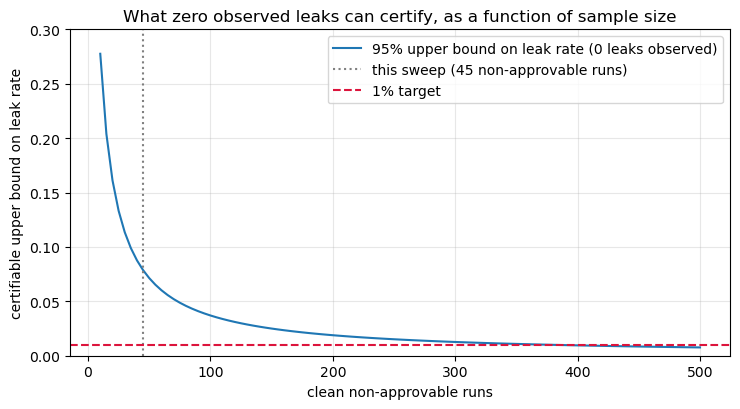

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ks = list(range(10, 501, 5))
bounds = [wilson_interval(0, k)[1] for k in ks]
ax.plot(ks, bounds, label="95% upper bound on leak rate (0 leaks observed)")
ax.axvline(non_approvable, color="grey", linestyle=":",
           label=f"this sweep ({non_approvable} non-approvable runs)")
ax.axhline(0.01, color="crimson", linestyle="--", label="1% target")
ax.set_xlabel("clean non-approvable runs")
ax.set_ylabel("certifiable upper bound on leak rate")
ax.set_ylim(0, 0.3)
ax.set_title("What zero observed leaks can certify, as a function of sample size")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## From metric to operating policy

The previous sweep spent several cells here hunting for a gate, a confidence threshold
or an amount ceiling, that could separate good approvals from leaks. None worked, because
the leaks overlapped the legitimate claims. That search is moot now, and the reason is
worth stating plainly: the operating-policy change those gates were groping toward has
already been made. `APPROVE_WITH_MONITORING` was the decision the agent used to absorb
stated risk into an approval. Removing it forces the same runs to `FLAG_FOR_REVIEW`
instead, which routes the risk to a human rather than gating it after the fact.

The check that matters now is whether any approval still carries risk the agent named.

In [9]:
INFRA = {"structured_output_unavailable"}
df["has_risk_flag"] = df["red_flags"].apply(
    lambda f: bool([x for x in f if x not in INFRA])
)

print("delivered decision x whether the run raised a risk flag")
print(pd.crosstab(df["decision"], df["has_risk_flag"]).to_string())
print()
risky_approvals = df[df["pred_approve"] & df["has_risk_flag"]]
print(f"approvals that carry a risk flag: {len(risky_approvals)}")
print()
risk_scen = ["fraud_new_customer", "near_limit", "velocity_repeat"]
print("fraud and risk scenarios, delivered decisions:")
print(df[df["scenario_id"].isin(risk_scen)]
      .groupby("scenario_id")["decision"].value_counts().to_string())

delivered decision x whether the run raised a risk flag
has_risk_flag    False  True 
decision                     
APPROVE             15      0
DENY                 6      5
FLAG_FOR_REVIEW      1     18
NEEDS_INFO           8      7

approvals that carry a risk flag: 0

fraud and risk scenarios, delivered decisions:
scenario_id         decision       
fraud_new_customer  FLAG_FOR_REVIEW    5
near_limit          FLAG_FOR_REVIEW    5
velocity_repeat     FLAG_FOR_REVIEW    5


No approval carries a risk flag. Every run that raised one was routed to
`FLAG_FOR_REVIEW`, `DENY` or `NEEDS_INFO`, and all fifteen fraud and risk runs went to
review. That is the policy working as a structural property of the decision set rather
than as a threshold anyone has to tune: the agent no longer has a decision that means
"approve but with reservations", so a reservation now has to become an escalation.

## Where this leaves the headline number

The single accuracy figure was never the right headline, and on this sweep splitting it
is what shows why. Reasoning accuracy is 100% and delivered accuracy is 98%, and the gap
between them is one run corrupted by the fallback parser, not one claim misjudged. An
averaged accuracy hides both the direction of that error and its cause.

Precision on the approve decision is the metric for a scorecard, since it isolates the
error that costs money. At 1.0 it passes where the previous sweep failed at 0.62, but the
honest reading is the confidence interval, not the point: 15 approve-eligible runs cannot
tell 1.0 from 0.80. Expected loss is what you would actually decide on, and with no
observed leak it cannot fail the agent the way it did before. It can only say the leak
rate is not yet bounded tightly enough to call safe, which needs about 380 clean
non-approvable runs to fix.

Three caveats stand behind all of it. The data is seeded, so this measures the scoring
loop rather than agreement with a real adjuster. Thirteen of sixty runs degraded to
heuristic synthesis under provider rate-limiting, which is the source of the one delivered
error and makes confidence unreliable as a signal. And a perfect confusion matrix on 60
runs is a small-sample result: the thing to carry forward is the leak the previous sweep
found and this one closed, not a claim that the closure is proven.